##Hyperparameter Tuning and Model Evaluation

Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [66]:
# Install packages
!pip install imbalanced-learn
!pip install dataframe_image
!pip install shap
!pip install dcurves --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [67]:
# Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import shap
from scipy import stats
import dataframe_image as dfi
import dcurves
from dcurves import dca, plot_graphs

# Preprocessing Libraries
from sklearn.model_selection import train_test_split

# Modeling Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.utils.class_weight import compute_class_weight
# Random Forest from scikit-learn
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# XGBoost
from xgboost import XGBClassifier, XGBRegressor

# SVM
from sklearn.svm import SVC

In [4]:
# Accessibility - to be applied to all plots
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colorblind safe palette
# Use Wong Color Blind Pallet Hex Codes
sns.set_palette("colorblind")

print("Libraries loaded and styling applied successfully")

Libraries loaded and styling applied successfully


In [5]:
# Load Datasets

# Load datasets
X_train_encoded = pd.read_csv('/content/drive/MyDrive/X_train_encoded_w5.csv')
X_test_encoded = pd.read_csv('/content/drive/MyDrive/X_test_encoded_w5.csv')
X_train_smote = pd.read_csv('/content/drive/MyDrive/X_train_smote_w5.csv')
y_train = pd.read_csv('/content/drive/MyDrive/y_train_w5.csv').squeeze() # convert y variables to 1D array
y_test = pd.read_csv('/content/drive/MyDrive/y_test_w5.csv').squeeze()
y_train_smote = pd.read_csv('/content/drive/MyDrive/y_train_smote_w5.csv').squeeze()

# Load fitted LR models for final comparison later
lr_standard = joblib.load('/content/drive/MyDrive/lr_standard_w5.pkl')
lr_csl = joblib.load('/content/drive/MyDrive/lr_csl_w5.pkl')

# Confirm
print("Datasets loaded successfully!")
print(f"X_train_encoded: {X_train_encoded.shape}")
print(f"X_test_encoded: {X_test_encoded.shape}")
print(f"X_train_smote: {X_train_smote.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

Datasets loaded successfully!
X_train_encoded: (213, 16)
X_test_encoded: (84, 16)
X_train_smote: (230, 16)
y_train: (213,)
y_test: (84,)


Random Forest Evaluation

In [6]:
# Random Forest - Baseline (Standard)
# No class weighting - baseline comparison
# Default hyperparameters before tuning
# Assumptions: data collected randomly/independently - yes
#              low multicollinearity - yes, confirmed via VIF


# Initialize baseline RF
rf_standard = RandomForestClassifier(
    n_estimators=100,    # default number of trees
    random_state=42,
    n_jobs=-1            # use all available cores
)

# Fit on original training set
rf_standard.fit(X_train_encoded, y_train)

print("Random Forest Standard model fitted successfully")
print(f"Number of features: {X_train_encoded.shape[1]}")
print(f"Number of trees: {rf_standard.n_estimators}")
print(f"Classes: {rf_standard.classes_}")

Random Forest Standard model fitted successfully
Number of features: 16
Number of trees: 100
Classes: [0 1]


In [7]:
# Stratified K-Fold Cross Validation - Prior to tuning

# Define stratified k-fold
skf_rf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',        # sensitivity
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

# Run cross validation
cv_results_rf = cross_validate(
    rf_standard,
    X_train_encoded,
    y_train,
    cv=skf_rf,
    scoring=scoring,
    return_train_score=True  # returns train scores for overfitting check
)

# Print results
print("Random Forest - Baseline/Standard - Cross Validation Results (k=10)")
print(f"{'Metric':<20} {'Train Mean':>12} {'Test Mean':>12} {'Test Std':>10}")

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    train_mean = cv_results_rf[f'train_{metric}'].mean()
    test_mean = cv_results_rf[f'test_{metric}'].mean()
    test_std = cv_results_rf[f'test_{metric}'].std()
    print(f"{metric:<20} {train_mean:>12.3f} {test_mean:>12.3f} {test_std:>10.3f}")

print("\nNote: Recall = Sensitivity")
print("High train vs low test score indicates overfitting")

Random Forest - Baseline/Standard - Cross Validation Results (k=10)
Metric                 Train Mean    Test Mean   Test Std
accuracy                    1.000        0.807      0.084
precision                   1.000        0.838      0.100
recall                      1.000        0.734      0.166
f1                          1.000        0.771      0.110
roc_auc                     1.000        0.878      0.071

Note: Recall = Sensitivity
High train vs low test score indicates overfitting


Random Forest Baseline is heavily overfit prior to hyperparameter tuning.

In [8]:
# Random Forest Standard - Test Set Evaluation

# Generate predictions
y_pred_rf_std = rf_standard.predict(X_test_encoded)
y_pred_proba_rf_std = rf_standard.predict_proba(X_test_encoded)[:, 1]

# Confusion matrix
cm_rf_std = confusion_matrix(y_test, y_pred_rf_std)
tn_rf_std, fp_rf_std, fn_rf_std, tp_rf_std = cm_rf_std.ravel()

# Calculate metrics
accuracy_rf_std = accuracy_score(y_test, y_pred_rf_std)
precision_rf_std = precision_score(y_test, y_pred_rf_std)
recall_rf_std = recall_score(y_test, y_pred_rf_std)
f1_rf_std = f1_score(y_test, y_pred_rf_std)
roc_auc_rf_std = roc_auc_score(y_test, y_pred_proba_rf_std)
specificity_rf_std = tn_rf_std / (tn_rf_std + fp_rf_std)

# Print results
print("Random Forest Standard - Test Set Results")
print("=" * 45)
print(f"Accuracy:    {accuracy_rf_std:.3f}")
print(f"Precision:   {precision_rf_std:.3f}")
print(f"Recall:      {recall_rf_std:.3f}  (Sensitivity)")
print(f"Specificity: {specificity_rf_std:.3f}")
print(f"F1:          {f1_rf_std:.3f}")
print(f"ROC-AUC:     {roc_auc_rf_std:.3f}")
print(f"\nTrue Negatives:  {tn_rf_std}")
print(f"False Positives: {fp_rf_std}")
print(f"True Positives:  {tp_rf_std}")
print(f"False Negatives: {fn_rf_std}")
print(f"\nMissed CVD cases (FN): {fn_rf_std}")
print(f"False alarms (FP):     {fp_rf_std}")

Random Forest Standard - Test Set Results
Accuracy:    0.810
Precision:   0.848
Recall:      0.718  (Sensitivity)
Specificity: 0.889
F1:          0.778
ROC-AUC:     0.909

True Negatives:  40
False Positives: 5
True Positives:  28
False Negatives: 11

Missed CVD cases (FN): 11
False alarms (FP):     5


In [9]:
# Random Forest - Baseline (CSL)
# Class weighting
# Default hyperparameters before tuning
# Assumptions: data collected randomly/independently - yes
#              low multicollinearity - yes, confirmed via VIF


# Initialize baseline RF
rf_csl = RandomForestClassifier(
    n_estimators=100, # default number of trees
    class_weight='balanced',
    random_state=42,
    n_jobs=-1            # use all available cores
)

# Fit on original training set
rf_csl.fit(X_train_encoded, y_train)

print("Random Forest CSL model fitted successfully")
print(f"Number of features: {X_train_encoded.shape[1]}")
print(f"Number of trees: {rf_csl.n_estimators}")
print(f"Classes: {rf_csl.classes_}")

Random Forest CSL model fitted successfully
Number of features: 16
Number of trees: 100
Classes: [0 1]


In [10]:
# Stratified K-Fold Cross Validation - Prior to tuning

# Define stratified k-fold
skf_rf_csl = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',        # sensitivity
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

# Run cross validation
cv_results_rf_csl = cross_validate(
    rf_csl,
    X_train_encoded,
    y_train,
    cv=skf_rf_csl,
    scoring=scoring,
    return_train_score=True  # returns train scores for overfitting check
)

# Print results
print("Random Forest - CSL - Cross Validation Results (k=10)")
print(f"{'Metric':<20} {'Train Mean':>12} {'Test Mean':>12} {'Test Std':>10}")

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    train_mean = cv_results_rf_csl[f'train_{metric}'].mean()
    test_mean = cv_results_rf_csl[f'test_{metric}'].mean()
    test_std = cv_results_rf_csl[f'test_{metric}'].std()
    print(f"{metric:<20} {train_mean:>12.3f} {test_mean:>12.3f} {test_std:>10.3f}")

print("\nNote: Recall = Sensitivity")
print("High train vs low test score indicates overfitting")

Random Forest - CSL - Cross Validation Results (k=10)
Metric                 Train Mean    Test Mean   Test Std
accuracy                    1.000        0.798      0.074
precision                   1.000        0.828      0.095
recall                      1.000        0.724      0.170
f1                          1.000        0.759      0.103
roc_auc                     1.000        0.881      0.065

Note: Recall = Sensitivity
High train vs low test score indicates overfitting


In [11]:
# Random Forest CSL - Test Set Evaluation

# Generate predictions
y_pred_rf_csl = rf_csl.predict(X_test_encoded)
y_pred_proba_rf_csl = rf_csl.predict_proba(X_test_encoded)[:, 1]

# Confusion matrix
cm_rf_csl = confusion_matrix(y_test, y_pred_rf_csl)
tn_rf_csl, fp_rf_csl, fn_rf_csl, tp_rf_csl = cm_rf_csl.ravel()

# Calculate metrics
accuracy_rf_csl = accuracy_score(y_test, y_pred_rf_csl)
precision_rf_csl = precision_score(y_test, y_pred_rf_csl)
recall_rf_csl = recall_score(y_test, y_pred_rf_csl)
f1_rf_csl = f1_score(y_test, y_pred_rf_csl)
roc_auc_rf_csl = roc_auc_score(y_test, y_pred_proba_rf_csl)
specificity_rf_csl = tn_rf_csl / (tn_rf_csl + fp_rf_csl)

# Print results
print("Random Forest CSL - Test Set Results")
print("=" * 45)
print(f"Accuracy:    {accuracy_rf_csl:.3f}")
print(f"Precision:   {precision_rf_csl:.3f}")
print(f"Recall:      {recall_rf_csl:.3f}  (Sensitivity)")
print(f"Specificity: {specificity_rf_csl:.3f}")
print(f"F1:          {f1_rf_csl:.3f}")
print(f"ROC-AUC:     {roc_auc_rf_csl:.3f}")
print(f"\nTrue Negatives:  {tn_rf_csl}")
print(f"False Positives: {fp_rf_csl}")
print(f"True Positives:  {tp_rf_csl}")
print(f"False Negatives: {fn_rf_csl}")
print(f"\nMissed CVD cases (FN): {fn_rf_csl}")
print(f"False alarms (FP):     {fp_rf_csl}")

Random Forest CSL - Test Set Results
Accuracy:    0.786
Precision:   0.839
Recall:      0.667  (Sensitivity)
Specificity: 0.889
F1:          0.743
ROC-AUC:     0.905

True Negatives:  40
False Positives: 5
True Positives:  26
False Negatives: 13

Missed CVD cases (FN): 13
False alarms (FP):     5


In [12]:
#If running this notebook for first time, please skip this cell

# If re-runnning this notebook code:
# Uncomment the following code to avoid running grid search again to save time

#grid_search_rf = joblib.load('/content/drive/MyDrive/grid_search_rf_w6.pkl')

#rf_tuned = joblib.load('/content/drive/MyDrive/rf_tuned_w6.pkl')

#print(f"RF best params: {grid_search_rf.best_params_}")
3print(f"RF tuned loaded successfully")

RF best params: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 4, 'n_estimators': 100}
RF tuned loaded successfully


In [ ]:
# Random Forest - Hyperparameter Tuning
# Grid Search with Repeated Stratified K-Fold
# Tuning to address severe overfitting identified in baseline


# Define parameter grid
# Focused on controlling tree depth and complexity
param_grid_rf = { # all combinations to test
    'n_estimators': [100, 200], # number of tress to build
    'max_depth': [3, 5, 10], # max depth of each tree
    'min_samples_leaf': [2, 4], # minimum samples at leaf nodes
    'class_weight': ['balanced', None] # test both balnced and none to find optimal CSL setting
}

# Repeated Stratified K-Fold for tuning
# More robust than standard k-fold for small datasets
rskf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=2,
    random_state=42
)

# Grid search
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=rskf,
    scoring='recall',    # optimize for sensitivity
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Fit on original training set
grid_search_rf.fit(X_train_encoded, y_train)

print(f"\nBest parameters: {grid_search_rf.best_params_}")
print(f"Best recall score: {grid_search_rf.best_score_:.3f}")

Fitting 20 folds for each of 24 candidates, totalling 480 fits


KeyboardInterrupt: 

In [13]:
# Save Grid Search Hyperparameters

joblib.dump(grid_search_rf, '/content/drive/MyDrive/grid_search_rf_w6.pkl')
print(f"Grid search saved!")
print(f"Best params: {grid_search_rf.best_params_}")
print(f"Best recall: {grid_search_rf.best_score_:.3f}")

Grid search saved!
Best params: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 4, 'n_estimators': 100}
Best recall: 0.766


In [14]:
# Random Forest - Tuned Model
# Using best hyperparameters
# Address overfitting identified in baseline

rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Fit on original training set
rf_tuned.fit(X_train_encoded, y_train)

print("Random Forest Tuned model fitted successfully")

Random Forest Tuned model fitted successfully


In [15]:
# Stratified K-Fold Cross Validation - Post tuning

# Define stratified k-fold
skf_rf_tuned = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',        # sensitivity
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

# Run cross validation
cv_results_rf_tuned = cross_validate(
    rf_tuned,
    X_train_encoded,
    y_train,
    cv=skf_rf_tuned,
    scoring=scoring,
    return_train_score=True  # returns train scores for overfitting check
)

# Print results
print("Random Forest - Tuned - Cross Validation Results (k=10)")
print(f"{'Metric':<20} {'Train Mean':>12} {'Test Mean':>12} {'Test Std':>10}")

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    train_mean = cv_results_rf_tuned[f'train_{metric}'].mean()
    test_mean = cv_results_rf_tuned[f'test_{metric}'].mean()
    test_std = cv_results_rf_tuned[f'test_{metric}'].std()
    print(f"{metric:<20} {train_mean:>12.3f} {test_mean:>12.3f} {test_std:>10.3f}")

print("\nNote: Recall = Sensitivity")
print("High train vs low test score indicates overfitting")

Random Forest - Tuned - Cross Validation Results (k=10)
Metric                 Train Mean    Test Mean   Test Std
accuracy                    0.881        0.821      0.079
precision                   0.901        0.847      0.083
recall                      0.832        0.756      0.163
f1                          0.865        0.788      0.105
roc_auc                     0.948        0.900      0.057

Note: Recall = Sensitivity
High train vs low test score indicates overfitting


In [16]:
# Random Forest CSL - Test Set Evaluation

# Generate predictions
y_pred_rf_tuned = rf_tuned.predict(X_test_encoded)
y_pred_proba_rf_tuned = rf_tuned.predict_proba(X_test_encoded)[:, 1]

# Confusion matrix
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
tn_rf_tuned, fp_rf_tuned, fn_rf_tuned, tp_rf_tuned = cm_rf_tuned.ravel()

# Calculate metrics
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned)
recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned)
roc_auc_rf_tuned = roc_auc_score(y_test, y_pred_proba_rf_tuned)
specificity_rf_tuned = tn_rf_tuned / (tn_rf_tuned + fp_rf_tuned)

# Print results
print("Random Forest Tuned - Test Set Results")
print("=" * 45)
print(f"Accuracy:    {accuracy_rf_tuned:.3f}")
print(f"Precision:   {precision_rf_tuned:.3f}")
print(f"Recall:      {recall_rf_tuned:.3f}  (Sensitivity)")
print(f"Specificity: {specificity_rf_tuned:.3f}")
print(f"F1:          {f1_rf_tuned:.3f}")
print(f"ROC-AUC:     {roc_auc_rf_tuned:.3f}")
print(f"\nTrue Negatives:  {tn_rf_tuned}")
print(f"False Positives: {fp_rf_tuned}")
print(f"True Positives:  {tp_rf_tuned}")
print(f"False Negatives: {fn_rf_tuned}")
print(f"\nMissed CVD cases (FN): {fn_rf_tuned}")
print(f"False alarms (FP):     {fp_rf_tuned}")

Random Forest Tuned - Test Set Results
Accuracy:    0.821
Precision:   0.853
Recall:      0.744  (Sensitivity)
Specificity: 0.889
F1:          0.795
ROC-AUC:     0.928

True Negatives:  40
False Positives: 5
True Positives:  29
False Negatives: 10

Missed CVD cases (FN): 10
False alarms (FP):     5


In [ ]:
# Saved RF Tuned model

joblib.dump(rf_tuned, '/content/drive/MyDrive/rf_tuned_w6.pkl')
print(f"RF Tuned model saved!")

RF Tuned model saved!


##XGBoost

In [17]:
# XGBoost - Baseline - Standard
# No class weighting - baseline comparison
# Default hyperparameters before tuning
# Assumptions: data collected randomly/independently
               # low multicollinearity - confirmed via VIF

xgb_standard = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',  # suppresses warning
    verbosity=0             # suppresses output
)

xgb_standard.fit(X_train_encoded, y_train)

print("XGBoost Standard model fitted successfully")
print(f"Number of features: {X_train_encoded.shape[1]}")
print(f"Classes: {xgb_standard.classes_}")

XGBoost Standard model fitted successfully
Number of features: 16
Classes: [0 1]


In [18]:
# Stratified K-Fold Cross Validation - Prior to tuning

# Define stratified k-fold
skf_xgb = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',        # sensitivity
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

# Run cross validation
cv_results_xgb = cross_validate(
    xgb_standard,
    X_train_encoded,
    y_train,
    cv=skf_xgb,
    scoring=scoring,
    return_train_score=True  # returns train scores for overfitting check
)

# Print results
print("XGBoost - Baseline/Standard - Cross Validation Results (k=10)")
print(f"{'Metric':<20} {'Train Mean':>12} {'Test Mean':>12} {'Test Std':>10}")

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    train_mean = cv_results_xgb[f'train_{metric}'].mean()
    test_mean = cv_results_xgb[f'test_{metric}'].mean()
    test_std = cv_results_xgb[f'test_{metric}'].std()
    print(f"{metric:<20} {train_mean:>12.3f} {test_mean:>12.3f} {test_std:>10.3f}")

print("\nNote: Recall = Sensitivity")
print("High train vs low test score indicates overfitting")

XGBoost - Baseline/Standard - Cross Validation Results (k=10)
Metric                 Train Mean    Test Mean   Test Std
accuracy                    1.000        0.783      0.077
precision                   1.000        0.804      0.120
recall                      1.000        0.747      0.161
f1                          1.000        0.756      0.091
roc_auc                     1.000        0.848      0.087

Note: Recall = Sensitivity
High train vs low test score indicates overfitting


In [19]:
# XGBoost Standard - Test Set Evaluation

# Generate predictions
y_pred_xgb = xgb_standard.predict(X_test_encoded)
y_pred_proba_xgb = xgb_standard.predict_proba(X_test_encoded)[:, 1]

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cm_xgb.ravel()

# Calculate metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
specificity_xgb = tn_xgb / (tn_xgb + fp_xgb)

# Print results
print("XGBoost Standard Baseline - Test Set Results")
print("=" * 45)
print(f"Accuracy:    {accuracy_xgb:.3f}")
print(f"Precision:   {precision_xgb:.3f}")
print(f"Recall:      {recall_xgb:.3f}  (Sensitivity)")
print(f"Specificity: {specificity_xgb:.3f}")
print(f"F1:          {f1_xgb:.3f}")
print(f"ROC-AUC:     {roc_auc_xgb:.3f}")
print(f"\nTrue Negatives:  {tn_xgb}")
print(f"False Positives: {fp_xgb}")
print(f"True Positives:  {tp_xgb}")
print(f"False Negatives: {fn_xgb}")
print(f"\nMissed CVD cases (FN): {fn_xgb}")
print(f"False alarms (FP):     {fp_xgb}")

XGBoost Standard Baseline - Test Set Results
Accuracy:    0.821
Precision:   0.853
Recall:      0.744  (Sensitivity)
Specificity: 0.889
F1:          0.795
ROC-AUC:     0.882

True Negatives:  40
False Positives: 5
True Positives:  29
False Negatives: 10

Missed CVD cases (FN): 10
False alarms (FP):     5


XGB CSL

In [20]:
# XGB - Baseline (CSL)
# Class weighting
# Default hyperparameters before tuning
# Assumptions: data collected randomly/independently - yes
#              low multicollinearity - yes, confirmed via VIF

# Calculate scale_pos_weight
spw = sum(y_train == 0) / sum(y_train == 1)
print(f"scale_pos_weight: {spw:.3f}")


# Initialize baseline RF
xgb_csl = XGBClassifier(
    n_estimators=100,
    scale_pos_weight = spw,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
)

# Fit on original training set
xgb_csl.fit(X_train_encoded, y_train)

print("XGB CSL model fitted successfully")
print(f"Number of features: {X_train_encoded.shape[1]}")
print(f"Number of trees: {xgb_csl.n_estimators}")
print(f"Classes: {xgb_csl.classes_}")

scale_pos_weight: 1.173
XGB CSL model fitted successfully
Number of features: 16
Number of trees: 100
Classes: [0 1]


In [21]:
# Stratified K-Fold Cross Validation - Prior to tuning

# Define stratified k-fold
skf_xgb_csl = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',        # sensitivity
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

# Run cross validation
cv_results_xgb_csl = cross_validate(
    xgb_csl,
    X_train_encoded,
    y_train,
    cv=skf_xgb_csl,
    scoring=scoring,
    return_train_score=True  # returns train scores for overfitting check
)

# Print results
print("XGBoost - CSL - Cross Validation Results (k=10)")
print(f"{'Metric':<20} {'Train Mean':>12} {'Test Mean':>12} {'Test Std':>10}")

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    train_mean = cv_results_xgb_csl[f'train_{metric}'].mean()
    test_mean = cv_results_xgb_csl[f'test_{metric}'].mean()
    test_std = cv_results_xgb_csl[f'test_{metric}'].std()
    print(f"{metric:<20} {train_mean:>12.3f} {test_mean:>12.3f} {test_std:>10.3f}")

print("\nNote: Recall = Sensitivity")
print("High train vs low test score indicates overfitting")

XGBoost - CSL - Cross Validation Results (k=10)
Metric                 Train Mean    Test Mean   Test Std
accuracy                    1.000        0.788      0.079
precision                   1.000        0.800      0.120
recall                      1.000        0.756      0.144
f1                          1.000        0.764      0.090
roc_auc                     1.000        0.843      0.087

Note: Recall = Sensitivity
High train vs low test score indicates overfitting


In [22]:
# XGBoost Standard - Test Set Evaluation

# Generate predictions
y_pred_xgb_csl = xgb_csl.predict(X_test_encoded)
y_pred_proba_xgb_csl = xgb_csl.predict_proba(X_test_encoded)[:, 1]

# Confusion matrix
cm_xgb_csl = confusion_matrix(y_test, y_pred_xgb_csl)
tn_xgb_csl, fp_xgb_csl, fn_xgb_csl, tp_xgb_csl = cm_xgb_csl.ravel()

# Calculate metrics
accuracy_xgb_csl = accuracy_score(y_test, y_pred_xgb_csl)
precision_xgb_csl = precision_score(y_test, y_pred_xgb_csl)
recall_xgb_csl = recall_score(y_test, y_pred_xgb_csl)
f1_xgb_csl = f1_score(y_test, y_pred_xgb_csl)
roc_auc_xgb_csl = roc_auc_score(y_test, y_pred_proba_xgb_csl)
specificity_xgb_csl = tn_xgb_csl / (tn_xgb_csl + fp_xgb_csl)

# Print results
print("XGBoost CSL Baseline - Test Set Results")
print("=" * 45)
print(f"Accuracy:    {accuracy_xgb_csl:.3f}")
print(f"Precision:   {precision_xgb_csl:.3f}")
print(f"Recall:      {recall_xgb_csl:.3f}  (Sensitivity)")
print(f"Specificity: {specificity_xgb_csl:.3f}")
print(f"F1:          {f1_xgb_csl:.3f}")
print(f"ROC-AUC:     {roc_auc_xgb_csl:.3f}")
print(f"\nTrue Negatives:  {tn_xgb_csl}")
print(f"False Positives: {fp_xgb_csl}")
print(f"True Positives:  {tp_xgb_csl}")
print(f"False Negatives: {fn_xgb_csl}")
print(f"\nMissed CVD cases (FN): {fn_xgb_csl}")
print(f"False alarms (FP):     {fp_xgb_csl}")

XGBoost CSL Baseline - Test Set Results
Accuracy:    0.762
Precision:   0.788
Recall:      0.667  (Sensitivity)
Specificity: 0.844
F1:          0.722
ROC-AUC:     0.879

True Negatives:  38
False Positives: 7
True Positives:  26
False Negatives: 13

Missed CVD cases (FN): 13
False alarms (FP):     7


In [23]:
#If running this notebook for first time, please skip this cell

# If re-runnning this notebook code:
# Uncomment the following code to avoid running grid search again to save time

# First round tuning
#grid_search_xgb = joblib.load('/content/drive/MyDrive/grid_search_xgb_w6.pkl')


# Second round tuning
#grid_search_xgb_r2 = joblib.load('/content/drive/MyDrive/grid_search_xgb_r2_w6.pkl')

#print(f"XGB best params: {grid_search_xgb.best_params_}")
##print(f"XGB tuned loaded successfully")

#print(f"XGB best params: {grid_search_xgb_r2.best_params_}")
#print(f"XGB Fully tuned loaded successfully")

XGB best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 1.1734693877551021, 'subsample': 0.8}
XGB tuned loaded successfully
XGB best params: {'gamma': 0.3, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 2}
XGB Fully tuned loaded successfully


In [ ]:
# XGBoost - Hyperparameter Tuning
# Grid Search with Repeated Stratified K-Fold
# XGBoost specific parameters for controlling overfitting

# Calculate scale_pos_weight for CSL
spw = sum(y_train == 0) / sum(y_train == 1)

# Define parameter grid
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'scale_pos_weight': [1, spw]  # 1=standard, spw=CSL
}

In [ ]:
# Repeated Stratified K-Fold
rskf_xgb = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=2,
    random_state=42
)

# Grid search
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    param_grid=param_grid_xgb,
    cv=rskf_xgb,
    scoring='recall',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Fit on original training set
grid_search_xgb.fit(X_train_encoded, y_train)

print(f"\nBest parameters: {grid_search_xgb.best_params_}")
print(f"Best recall score: {grid_search_xgb.best_score_:.3f}")

Fitting 20 folds for each of 72 candidates, totalling 1440 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 1.1734693877551021, 'subsample': 0.8}
Best recall score: 0.782


In [24]:
# Save grid search results

joblib.dump(grid_search_xgb, '/content/drive/MyDrive/grid_search_xgb_w6.pkl')
print(f"XGBoost grid search saved!")
print(f"Best params: {grid_search_xgb.best_params_}")
print(f"Best recall: {grid_search_xgb.best_score_:.3f}")

XGBoost grid search saved!
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 1.1734693877551021, 'subsample': 0.8}
Best recall: 0.782


In [25]:
# XGBoost - Tuned Model
# Using best parameters from grid search
# CSL confirmed by grid search - scale_pos_weight applied

xgb_tuned = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# Fit on original training set
xgb_tuned.fit(X_train_encoded, y_train)

print("XGBoost Tuned model fitted successfully")
print(f"Best parameters applied:")
print(f"  n_estimators: 100")
print(f"  max_depth: 3")
print(f"  learning_rate: 0.1")
print(f"  subsample: 0.8")
print(f"  scale_pos_weight: {spw:.3f} (CSL)")

XGBoost Tuned model fitted successfully
Best parameters applied:
  n_estimators: 100
  max_depth: 3
  learning_rate: 0.1
  subsample: 0.8
  scale_pos_weight: 1.173 (CSL)


In [26]:
# Stratified K-Fold Cross Validation - Post tuning

# Define stratified k-fold
skf_xgb_tuned = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',        # sensitivity
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

# Run cross validation
cv_results_xgb_tuned = cross_validate(
    xgb_tuned,
    X_train_encoded,
    y_train,
    cv=skf_xgb_tuned,
    scoring=scoring,
    return_train_score=True  # returns train scores for overfitting check
)

# Print results
print("XGBoost - Tuned - Cross Validation Results (k=10)")
print(f"{'Metric':<20} {'Train Mean':>12} {'Test Mean':>12} {'Test Std':>10}")

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    train_mean = cv_results_xgb_tuned[f'train_{metric}'].mean()
    test_mean = cv_results_xgb_tuned[f'test_{metric}'].mean()
    test_std = cv_results_xgb_tuned[f'test_{metric}'].std()
    print(f"{metric:<20} {train_mean:>12.3f} {test_mean:>12.3f} {test_std:>10.3f}")

print("\nNote: Recall = Sensitivity")
print("High train vs low test score indicates overfitting")

XGBoost - Tuned - Cross Validation Results (k=10)
Metric                 Train Mean    Test Mean   Test Std
accuracy                    0.982        0.793      0.078
precision                   0.990        0.794      0.107
recall                      0.972        0.776      0.148
f1                          0.981        0.771      0.085
roc_auc                     0.998        0.859      0.080

Note: Recall = Sensitivity
High train vs low test score indicates overfitting


In [ ]:
# XGBoost - Second Round Tuning
# Focused on regularization parameters
# Addressing residual overfitting from round 1


param_grid_xgb_r2 = {
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

# Keep best params from round 1 as base
rskf_xgb_r2 = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=2,
    random_state=42
)

grid_search_xgb_r2 = GridSearchCV(
    estimator=XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        scale_pos_weight=spw,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    param_grid=param_grid_xgb_r2,
    cv=rskf_xgb_r2,
    scoring='recall',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search_xgb_r2.fit(X_train_encoded, y_train)

print(f"\nBest parameters round 2: {grid_search_xgb_r2.best_params_}")
print(f"Best recall score: {grid_search_xgb_r2.best_score_:.3f}")

Fitting 20 folds for each of 81 candidates, totalling 1620 fits

Best parameters round 2: {'gamma': 0.3, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 2}
Best recall score: 0.817


In [27]:
# Save second round tuning

joblib.dump(grid_search_xgb_r2, '/content/drive/MyDrive/grid_search_xgb_r2_w6.pkl')
print(f"XGBoost grid search round 2 saved!")
print(f"Best params: {grid_search_xgb_r2.best_params_}")
print(f"Best recall: {grid_search_xgb_r2.best_score_:.3f}")

XGBoost grid search round 2 saved!
Best params: {'gamma': 0.3, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 2}
Best recall: 0.817


In [28]:
# XGBoost - Fully Tuned Model
# Combining best parameters from both tuning rounds
# Round 1: n_estimators, max_depth, learning_rate, subsample
# Round 2: gamma, min_child_weight, reg_alpha, reg_lambda


xgb_tuned_r2 = XGBClassifier(
    # Round 1 best parameters
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    scale_pos_weight=spw,
    # Round 2 best parameters
    gamma=0.3,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=2,
    # Fixed parameters
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_tuned_r2.fit(X_train_encoded, y_train)

print("XGBoost Fully Tuned model fitted successfully")
print(f"\nAll parameters applied:")
print(f"  Round 1: n_estimators=100, max_depth=3, learning_rate=0.1, subsample=0.8")
print(f"  Round 2: gamma=0.3, min_child_weight=5, reg_alpha=0.1, reg_lambda=2")
print(f"  CSL: scale_pos_weight={spw:.3f}")

XGBoost Fully Tuned model fitted successfully

All parameters applied:
  Round 1: n_estimators=100, max_depth=3, learning_rate=0.1, subsample=0.8
  Round 2: gamma=0.3, min_child_weight=5, reg_alpha=0.1, reg_lambda=2
  CSL: scale_pos_weight=1.173


In [29]:
# Stratified K-Fold Cross Validation - Post tuning - Round 2

# Define stratified k-fold
skf_xgb_tuned_r2 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',        # sensitivity
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

# Run cross validation
cv_results_xgb_tuned_r2 = cross_validate(
    xgb_tuned_r2,
    X_train_encoded,
    y_train,
    cv=skf_xgb_tuned_r2,
    scoring=scoring,
    return_train_score=True  # returns train scores for overfitting check
)

# Print results
print("XGBoost - Fully Tuned - Cross Validation Results (k=10)")
print(f"{'Metric':<20} {'Train Mean':>12} {'Test Mean':>12} {'Test Std':>10}")

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    train_mean = cv_results_xgb_tuned_r2[f'train_{metric}'].mean()
    test_mean = cv_results_xgb_tuned_r2[f'test_{metric}'].mean()
    test_std = cv_results_xgb_tuned_r2[f'test_{metric}'].std()
    print(f"{metric:<20} {train_mean:>12.3f} {test_mean:>12.3f} {test_std:>10.3f}")

print("\nNote: Recall = Sensitivity")
print("High train vs low test score indicates overfitting")

XGBoost - Fully Tuned - Cross Validation Results (k=10)
Metric                 Train Mean    Test Mean   Test Std
accuracy                    0.905        0.807      0.061
precision                   0.918        0.792      0.093
recall                      0.871        0.817      0.147
f1                          0.894        0.791      0.077
roc_auc                     0.962        0.907      0.059

Note: Recall = Sensitivity
High train vs low test score indicates overfitting


In [30]:
# XGBoost Fully Tuned - Test Set Evaluation

# Generate predictions
y_pred_xgb_tuned_r2 = xgb_tuned_r2.predict(X_test_encoded)
y_pred_proba_xgb_tuned_r2 = xgb_tuned_r2.predict_proba(X_test_encoded)[:, 1]

# Confusion matrix
cm_xgb_tuned_r2 = confusion_matrix(y_test, y_pred_xgb_tuned_r2)
tn_xgb_tuned_r2, fp_xgb_tuned_r2, fn_xgb_tuned_r2, tp_xgb_tuned_r2 = cm_xgb_tuned_r2.ravel()

# Calculate metrics
accuracy_xgb_tuned_r2 = accuracy_score(y_test, y_pred_xgb_tuned_r2)
precision_xgb_tuned_r2 = precision_score(y_test, y_pred_xgb_tuned_r2)
recall_xgb_tuned_r2 = recall_score(y_test, y_pred_xgb_tuned_r2)
f1_xgb_tuned_r2 = f1_score(y_test, y_pred_xgb_tuned_r2)
roc_auc_xgb_tuned_r2 = roc_auc_score(y_test, y_pred_proba_xgb_tuned_r2)
specificity_xgb_tuned_r2 = tn_xgb_tuned_r2/ (tn_xgb_tuned_r2 + fp_xgb_tuned_r2)

# Print results
print("XGBoost Fully Tuned - Test Set Results")
print("=" * 45)
print(f"Accuracy:    {accuracy_xgb_tuned_r2:.3f}")
print(f"Precision:   {precision_xgb_tuned_r2:.3f}")
print(f"Recall:      {recall_xgb_tuned_r2:.3f}  (Sensitivity)")
print(f"Specificity: {specificity_xgb_tuned_r2:.3f}")
print(f"F1:          {f1_xgb_tuned_r2:.3f}")
print(f"ROC-AUC:     {roc_auc_xgb_tuned_r2:.3f}")
print(f"\nTrue Negatives:  {tn_xgb_tuned_r2}")
print(f"False Positives: {fp_xgb_tuned_r2}")
print(f"True Positives:  {tp_xgb_tuned_r2}")
print(f"False Negatives: {fn_xgb_tuned_r2}")
print(f"\nMissed CVD cases (FN): {fn_xgb_tuned_r2}")
print(f"False alarms (FP):     {fp_xgb_tuned_r2}")

XGBoost Fully Tuned - Test Set Results
Accuracy:    0.821
Precision:   0.853
Recall:      0.744  (Sensitivity)
Specificity: 0.889
F1:          0.795
ROC-AUC:     0.917

True Negatives:  40
False Positives: 5
True Positives:  29
False Negatives: 10

Missed CVD cases (FN): 10
False alarms (FP):     5


In [ ]:
joblib.dump(xgb_tuned_r2, '/content/drive/MyDrive/xgb_tuned_r2_w6.pkl')
print(f"XGB Fully Tuned model saved!")

XGB Fully Tuned model saved!


##SVM

In [31]:
# Verify class weights

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
print(f"Class 0 weight: {weights[0]:.3f}")
print(f"Class 1 weight: {weights[1]:.3f}")

Class 0 weight: 0.926
Class 1 weight: 1.087


In [32]:
# SVM - Baseline

svm_linear_std = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

svm_linear_std.fit(X_train_encoded, y_train)
print("SVM Linear baseline fitted")


SVM Linear baseline fitted


In [33]:
# Stratified K-Fold Cross Validation - SVM Linear Baseline

# Define stratified k-fold
skf_svm_linear_std = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

# Run cross validation
cv_results_svm_linear_std = cross_validate(
    svm_linear_std,
    X_train_encoded,
    y_train,
    cv=skf_svm_linear_std,
    scoring=scoring,
    return_train_score=True
)

# Print results
print("SVM Linear - Baseline - Cross Validation Results (k=10)")
print(f"{'Metric':<20} {'Train Mean':>12} {'Test Mean':>12} {'Test Std':>10}")

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    train_mean = cv_results_svm_linear_std[f'train_{metric}'].mean()
    test_mean = cv_results_svm_linear_std[f'test_{metric}'].mean()
    test_std = cv_results_svm_linear_std[f'test_{metric}'].std()
    print(f"{metric:<20} {train_mean:>12.3f} {test_mean:>12.3f} {test_std:>10.3f}")

print("\nNote: Recall = Sensitivity")
print("High train vs low test score indicates overfitting")

SVM Linear - Baseline - Cross Validation Results (k=10)
Metric                 Train Mean    Test Mean   Test Std
accuracy                    0.861        0.784      0.064
precision                   0.888        0.797      0.099
recall                      0.799        0.734      0.147
f1                          0.841        0.752      0.085
roc_auc                     0.923        0.884      0.062

Note: Recall = Sensitivity
High train vs low test score indicates overfitting


In [34]:
# SVM Linear - Baseline - Test Set Evaluation

# Generate predictions
y_pred_svm_linear_std = svm_linear_std.predict(X_test_encoded)
y_pred_proba_svm_linear_std = svm_linear_std.predict_proba(X_test_encoded)[:, 1]

# Confusion matrix
cm_svm_linear_std = confusion_matrix(y_test, y_pred_svm_linear_std)
tn_svm_linear_std, fp_svm_linear_std, fn_svm_linear_std, tp_svm_linear_std = cm_svm_linear_std.ravel()

# Calculate metrics
accuracy_svm_linear_std = accuracy_score(y_test, y_pred_svm_linear_std)
precision_svm_linear_std = precision_score(y_test, y_pred_svm_linear_std)
recall_svm_linear_std = recall_score(y_test, y_pred_svm_linear_std)
f1_svm_linear_std = f1_score(y_test, y_pred_svm_linear_std)
roc_auc_svm_linear_std = roc_auc_score(y_test, y_pred_proba_svm_linear_std)
specificity_svm_linear_std = tn_svm_linear_std / (tn_svm_linear_std + fp_svm_linear_std)

# Print results
print("SVM Linear - Baseline - Test Set Results")
print("=" * 45)
print(f"Accuracy:    {accuracy_svm_linear_std:.3f}")
print(f"Precision:   {precision_svm_linear_std:.3f}")
print(f"Recall:      {recall_svm_linear_std:.3f}  (Sensitivity)")
print(f"Specificity: {specificity_svm_linear_std:.3f}")
print(f"F1:          {f1_svm_linear_std:.3f}")
print(f"ROC-AUC:     {roc_auc_svm_linear_std:.3f}")
print(f"\nTrue Negatives:  {tn_svm_linear_std}")
print(f"False Positives: {fp_svm_linear_std}")
print(f"True Positives:  {tp_svm_linear_std}")
print(f"False Negatives: {fn_svm_linear_std}")
print(f"\nMissed CVD cases (FN): {fn_svm_linear_std}")
print(f"False alarms (FP):     {fp_svm_linear_std}")

SVM Linear - Baseline - Test Set Results
Accuracy:    0.857
Precision:   0.909
Recall:      0.769  (Sensitivity)
Specificity: 0.933
F1:          0.833
ROC-AUC:     0.946

True Negatives:  42
False Positives: 3
True Positives:  30
False Negatives: 9

Missed CVD cases (FN): 9
False alarms (FP):     3


In [35]:
# SVM Linear - CSL - Hyperparameter Tuning
# C controls margin width and regularization strength
# Lower C = wider margin, more misclassifications allowed = simpler boundary
# Higher C = narrower margin, fewer misclassifications = risk of overfitting

param_grid_svm_linear = {
    'C': [0.01, 0.1, 1, 10, 100]
}

In [37]:
rskf_svm_linear = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=2,
    random_state=42
)

grid_search_svm_linear = GridSearchCV(
    estimator=SVC(
        kernel='linear',
        class_weight='balanced',
        probability=True,
        random_state=42
    ),
    param_grid=param_grid_svm_linear,
    cv=rskf_svm_linear,
    scoring='recall',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search_svm_linear.fit(X_train_encoded, y_train)

# Save immediately
joblib.dump(grid_search_svm_linear, '/content/drive/MyDrive/grid_search_svm_linear_w6.pkl')
print("Grid search saved")

print(f"\nBest C: {grid_search_svm_linear.best_params_}")
print(f"Best CV recall: {grid_search_svm_linear.best_score_:.3f}")

Fitting 20 folds for each of 5 candidates, totalling 100 fits
Grid search saved

Best C: {'C': 1}
Best CV recall: 0.761


In [38]:
# Extract best model from grid search
svm_linear_csl = grid_search_svm_linear.best_estimator_

# Save best model
joblib.dump(svm_linear_csl, '/content/drive/MyDrive/svm_linear_csl_w6.pkl')
print(f"SVM Linear CSL saved!")
print(f"Best params: {grid_search_svm_linear.best_params_}")
print(f"Best recall: {grid_search_svm_linear.best_score_:.3f}")

SVM Linear CSL saved!
Best params: {'C': 1}
Best recall: 0.761


In [39]:
# SVM Linear - CSL - Cross Validation

skf_svm_linear_csl = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

cv_results_svm_linear_csl = cross_validate(
    svm_linear_csl,
    X_train_encoded,
    y_train,
    cv=skf_svm_linear_csl,
    scoring=scoring,
    return_train_score=True
)

print("SVM Linear - CSL - Cross Validation Results (k=10)")
print(f"{'Metric':<20} {'Train Mean':>12} {'Test Mean':>12} {'Test Std':>10}")

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    train_mean = cv_results_svm_linear_csl[f'train_{metric}'].mean()
    test_mean = cv_results_svm_linear_csl[f'test_{metric}'].mean()
    test_std = cv_results_svm_linear_csl[f'test_{metric}'].std()
    print(f"{metric:<20} {train_mean:>12.3f} {test_mean:>12.3f} {test_std:>10.3f}")

print("\nNote: Recall = Sensitivity")
print("High train vs low test score indicates overfitting")

SVM Linear - CSL - Cross Validation Results (k=10)
Metric                 Train Mean    Test Mean   Test Std
accuracy                    0.856        0.774      0.081
precision                   0.858        0.779      0.108
recall                      0.824        0.734      0.147
f1                          0.840        0.746      0.098
roc_auc                     0.923        0.883      0.060

Note: Recall = Sensitivity
High train vs low test score indicates overfitting


In [40]:
# SVM Linear - CSL - Test Set Evaluation

# Generate predictions
y_pred_svm_linear_csl = svm_linear_csl.predict(X_test_encoded)
y_pred_proba_svm_linear_csl = svm_linear_csl.predict_proba(X_test_encoded)[:, 1]

# Confusion matrix
cm_svm_linear_csl = confusion_matrix(y_test, y_pred_svm_linear_csl)
tn_svm_linear_csl, fp_svm_linear_csl, fn_svm_linear_csl, tp_svm_linear_csl = cm_svm_linear_csl.ravel()

# Calculate metrics
accuracy_svm_linear_csl = accuracy_score(y_test, y_pred_svm_linear_csl)
precision_svm_linear_csl = precision_score(y_test, y_pred_svm_linear_csl)
recall_svm_linear_csl = recall_score(y_test, y_pred_svm_linear_csl)
f1_svm_linear_csl = f1_score(y_test, y_pred_svm_linear_csl)
roc_auc_svm_linear_csl = roc_auc_score(y_test, y_pred_proba_svm_linear_csl)
specificity_svm_linear_csl = tn_svm_linear_csl / (tn_svm_linear_csl + fp_svm_linear_csl)

# Print results
print("SVM Linear - CSL - Test Set Results")
print("=" * 45)
print(f"Accuracy:    {accuracy_svm_linear_csl:.3f}")
print(f"Precision:   {precision_svm_linear_csl:.3f}")
print(f"Recall:      {recall_svm_linear_csl:.3f}  (Sensitivity)")
print(f"Specificity: {specificity_svm_linear_csl:.3f}")
print(f"F1:          {f1_svm_linear_csl:.3f}")
print(f"ROC-AUC:     {roc_auc_svm_linear_csl:.3f}")
print(f"\nTrue Negatives:  {tn_svm_linear_csl}")
print(f"False Positives: {fp_svm_linear_csl}")
print(f"True Positives:  {tp_svm_linear_csl}")
print(f"False Negatives: {fn_svm_linear_csl}")
print(f"\nMissed CVD cases (FN): {fn_svm_linear_csl}")
print(f"False alarms (FP):     {fp_svm_linear_csl}")

SVM Linear - CSL - Test Set Results
Accuracy:    0.857
Precision:   0.886
Recall:      0.795  (Sensitivity)
Specificity: 0.911
F1:          0.838
ROC-AUC:     0.944

True Negatives:  41
False Positives: 4
True Positives:  31
False Negatives: 8

Missed CVD cases (FN): 8
False alarms (FP):     4


SVM RBF Baseline

In [41]:
# SVM RBF - Baseline - Fit on training data

svm_rbf = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_rbf.fit(X_train_encoded, y_train)
print("SVM RBF baseline fitted")

SVM RBF baseline fitted


In [42]:
# SVM RBF - Baseline - Cross Validation

skf_svm_rbf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

cv_results_svm_rbf = cross_validate(
    svm_rbf,
    X_train_encoded,
    y_train,
    cv=skf_svm_rbf,
    scoring=scoring,
    return_train_score=True
)

print("SVM RBF - Baseline - Cross Validation Results (k=10)")
print(f"{'Metric':<20} {'Train Mean':>12} {'Test Mean':>12} {'Test Std':>10}")

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    train_mean = cv_results_svm_rbf[f'train_{metric}'].mean()
    test_mean = cv_results_svm_rbf[f'test_{metric}'].mean()
    test_std = cv_results_svm_rbf[f'test_{metric}'].std()
    print(f"{metric:<20} {train_mean:>12.3f} {test_mean:>12.3f} {test_std:>10.3f}")

print("\nNote: Recall = Sensitivity")
print("High train vs low test score indicates overfitting")

SVM RBF - Baseline - Cross Validation Results (k=10)
Metric                 Train Mean    Test Mean   Test Std
accuracy                    0.887        0.802      0.052
precision                   0.928        0.850      0.103
recall                      0.817        0.723      0.145
f1                          0.869        0.766      0.071
roc_auc                     0.958        0.873      0.073

Note: Recall = Sensitivity
High train vs low test score indicates overfitting


In [43]:
# SVM RBF - Baseline - Test Set Evaluation

# Generate predictions
y_pred_svm_rbf = svm_rbf.predict(X_test_encoded)
y_pred_proba_svm_rbf = svm_rbf.predict_proba(X_test_encoded)[:, 1]

# Confusion matrix
cm_svm_rbf = confusion_matrix(y_test, y_pred_svm_rbf)
tn_svm_rbf, fp_svm_rbf, fn_svm_rbf, tp_svm_rbf = cm_svm_rbf.ravel()

# Calculate metrics
accuracy_svm_rbf = accuracy_score(y_test, y_pred_svm_rbf)
precision_svm_rbf = precision_score(y_test, y_pred_svm_rbf)
recall_svm_rbf = recall_score(y_test, y_pred_svm_rbf)
f1_svm_rbf = f1_score(y_test, y_pred_svm_rbf)
roc_auc_svm_rbf = roc_auc_score(y_test, y_pred_proba_svm_rbf)
specificity_svm_rbf = tn_svm_rbf / (tn_svm_rbf + fp_svm_rbf)

# Print results
print("SVM RBF - Baseline - Test Set Results")
print("=" * 45)
print(f"Accuracy:    {accuracy_svm_rbf:.3f}")
print(f"Precision:   {precision_svm_rbf:.3f}")
print(f"Recall:      {recall_svm_rbf:.3f}  (Sensitivity)")
print(f"Specificity: {specificity_svm_rbf:.3f}")
print(f"F1:          {f1_svm_rbf:.3f}")
print(f"ROC-AUC:     {roc_auc_svm_rbf:.3f}")
print(f"\nTrue Negatives:  {tn_svm_rbf}")
print(f"False Positives: {fp_svm_rbf}")
print(f"True Positives:  {tp_svm_rbf}")
print(f"False Negatives: {fn_svm_rbf}")
print(f"\nMissed CVD cases (FN): {fn_svm_rbf}")
print(f"False alarms (FP):     {fp_svm_rbf}")

SVM RBF - Baseline - Test Set Results
Accuracy:    0.857
Precision:   0.909
Recall:      0.769  (Sensitivity)
Specificity: 0.933
F1:          0.833
ROC-AUC:     0.940

True Negatives:  42
False Positives: 3
True Positives:  30
False Negatives: 9

Missed CVD cases (FN): 9
False alarms (FP):     3


In [44]:
# Confirmation that metrics were not overwritten

# LR Baseline - Recalculate metrics with suffixed variable names
# Original generic variables may have been overwritten by subsequent models

y_pred_lr_std = lr_standard.predict(X_test_encoded)
y_pred_proba_lr_std = lr_standard.predict_proba(X_test_encoded)[:, 1]

cm_lr_std = confusion_matrix(y_test, y_pred_lr_std)
tn_lr_std, fp_lr_std, fn_lr_std, tp_lr_std = cm_lr_std.ravel()

accuracy_lr_std = accuracy_score(y_test, y_pred_lr_std)
precision_lr_std = precision_score(y_test, y_pred_lr_std)
recall_lr_std = recall_score(y_test, y_pred_lr_std)
f1_lr_std = f1_score(y_test, y_pred_lr_std)
roc_auc_lr_std = roc_auc_score(y_test, y_pred_proba_lr_std)
specificity_lr_std = tn_lr_std / (tn_lr_std + fp_lr_std)

print("LR Baseline metrics recalculated with suffixed names")
print(f"Recall: {recall_lr_std:.3f} | Specificity: {specificity_lr_std:.3f} | AUC: {roc_auc_lr_std:.3f}")

LR Baseline metrics recalculated with suffixed names
Recall: 0.744 | Specificity: 0.911 | AUC: 0.932


In [45]:
# LR CSL - Recalculate metrics for comparison table
y_pred_lr_csl = lr_csl.predict(X_test_encoded)
y_pred_proba_lr_csl = lr_csl.predict_proba(X_test_encoded)[:, 1]

cm_csl = confusion_matrix(y_test, y_pred_lr_csl)
tn_csl, fp_csl, fn_csl, tp_csl = cm_csl.ravel()

accuracy_csl = accuracy_score(y_test, y_pred_lr_csl)
precision_csl = precision_score(y_test, y_pred_lr_csl)
recall_csl = recall_score(y_test, y_pred_lr_csl)
f1_csl = f1_score(y_test, y_pred_lr_csl)
roc_auc_csl = roc_auc_score(y_test, y_pred_proba_lr_csl)
specificity_csl = tn_csl / (tn_csl + fp_csl)

print(f"LR CSL metrics recalculated")
print(f"Recall: {recall_csl:.3f} | Specificity: {specificity_csl:.3f} | AUC: {roc_auc_csl:.3f}")

LR CSL metrics recalculated
Recall: 0.795 | Specificity: 0.911 | AUC: 0.933


## Model Comparisions

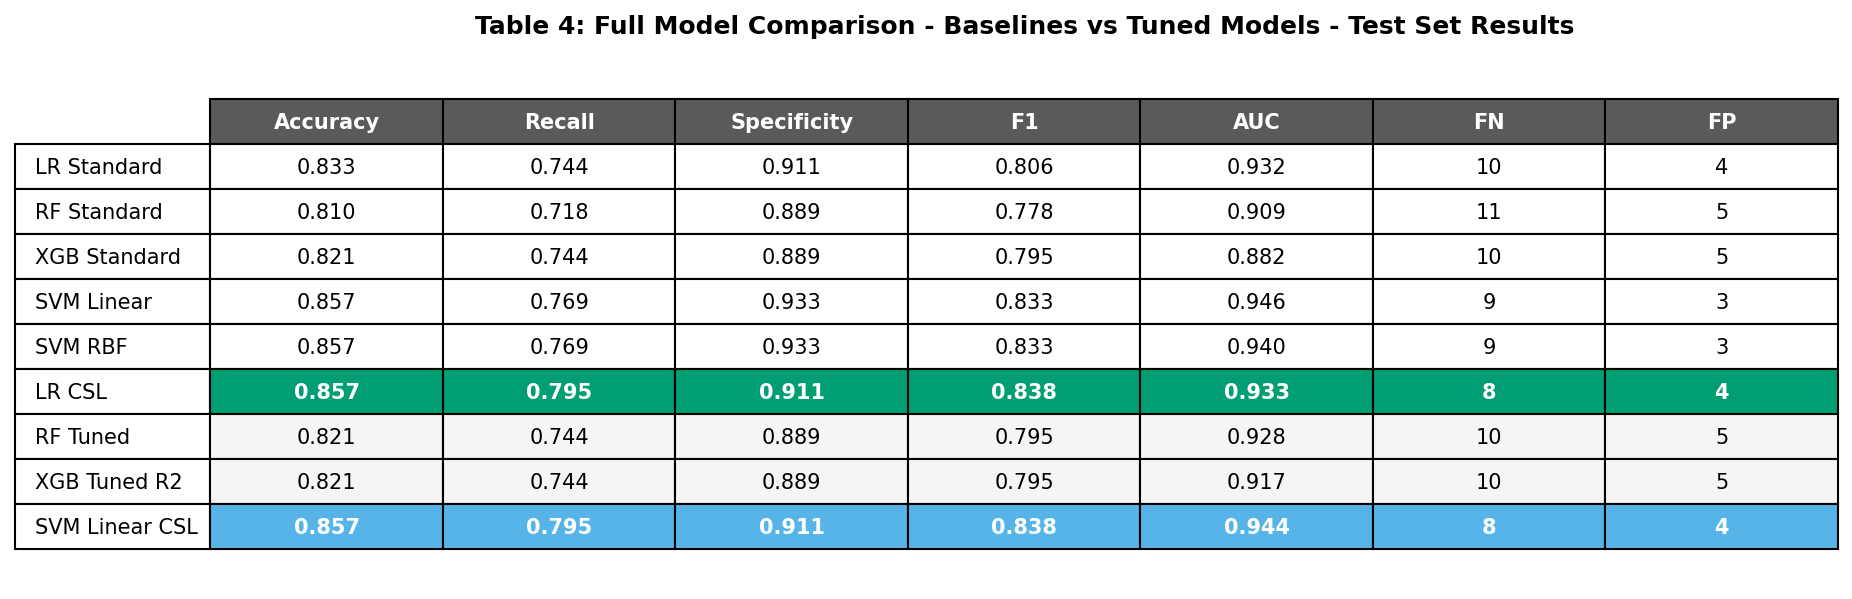

Table 4 saved


In [46]:
# Build comparison dataframe
data = {
    'Accuracy': [accuracy_lr_std, accuracy_rf_std, accuracy_xgb, accuracy_svm_linear_std, accuracy_svm_rbf,
                 accuracy_csl, accuracy_rf_tuned, accuracy_xgb_tuned_r2, accuracy_svm_linear_csl],
    'Recall': [recall_lr_std, recall_rf_std, recall_xgb, recall_svm_linear_std, recall_svm_rbf,
               recall_csl, recall_rf_tuned, recall_xgb_tuned_r2, recall_svm_linear_csl],
    'Specificity': [specificity_lr_std, specificity_rf_std, specificity_xgb, specificity_svm_linear_std, specificity_svm_rbf,
                    specificity_csl, specificity_rf_tuned, specificity_xgb_tuned_r2, specificity_svm_linear_csl],
    'F1': [f1_lr_std, f1_rf_std, f1_xgb, f1_svm_linear_std, f1_svm_rbf,
           f1_csl, f1_rf_tuned, f1_xgb_tuned_r2, f1_svm_linear_csl],
    'AUC': [roc_auc_lr_std, roc_auc_rf_std, roc_auc_xgb, roc_auc_svm_linear_std, roc_auc_svm_rbf,
            roc_auc_csl, roc_auc_rf_tuned, roc_auc_xgb_tuned_r2, roc_auc_svm_linear_csl],
    'FN': [fn_lr_std, fn_rf_std, fn_xgb, fn_svm_linear_std, fn_svm_rbf,
           fn_csl, fn_rf_tuned, fn_xgb_tuned_r2, fn_svm_linear_csl],
    'FP': [fp_lr_std, fp_rf_std, fp_xgb, fp_svm_linear_std, fp_svm_rbf,
           fp_csl, fp_rf_tuned, fp_xgb_tuned_r2, fp_svm_linear_csl],
}

index = [
    'LR Standard', 'RF Standard', 'XGB Standard', 'SVM Linear', 'SVM RBF',
    'LR CSL', 'RF Tuned', 'XGB Tuned R2', 'SVM Linear CSL'
]

comparison_df = pd.DataFrame(data, index=index)

# Round for display
comparison_df_display = comparison_df.copy()
for col in ['Accuracy', 'Recall', 'Specificity', 'F1', 'AUC']:
    comparison_df_display[col] = comparison_df_display[col].map('{:.3f}'.format)
for col in ['FN', 'FP']:
    comparison_df_display[col] = comparison_df_display[col].map('{:.0f}'.format)

# Plot
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.axis('off')

comp_table = ax.table( # create table object
    cellText=comparison_df_display.values, # data to display
    rowLabels=comparison_df_display.index, # row names
    colLabels=comparison_df_display.columns, # coloumn names
    loc='center', # center table
    cellLoc='center' # center text within cell
)

comp_table.scale(1, 1.8) # scales table size for readability, height width
comp_table.auto_set_font_size(False) # turn off automatic font sizing
comp_table.set_fontsize(10) # manually set font size

# Style header row
for j in range(len(comparison_df_display.columns)):
    comp_table[0, j].set_facecolor('#5a5a5a')
    comp_table[0, j].set_text_props(color='white', fontweight='bold')

# Style row labels
for i in range(len(comparison_df_display.index)):
    comp_table[i+1, -1].set_text_props(fontweight='normal')

# Highlight best — LR CSL
for j in range(len(comparison_df_display.columns)):
    comp_table[6, j].set_facecolor('#009E73')
    comp_table[6, j].set_text_props(color='white', fontweight='bold')

# Highlight runner up — SVM Linear CSL
for j in range(len(comparison_df_display.columns)):
    comp_table[9, j].set_facecolor('#56B4E9')
    comp_table[9, j].set_text_props(color='white', fontweight='bold')

# Add divider between baselines and tuned — grey shading on tuned section
for i in [7, 8]:
    for j in range(len(comparison_df_display.columns)):
        comp_table[i, j].set_facecolor('#f5f5f5')

plt.title('Table 4: Full Model Comparison - Baselines vs Tuned Models - Test Set Results',
          fontsize=12, fontweight='bold', pad=15)

plt.savefig('table4_full_model_comparison.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Table 4 saved")

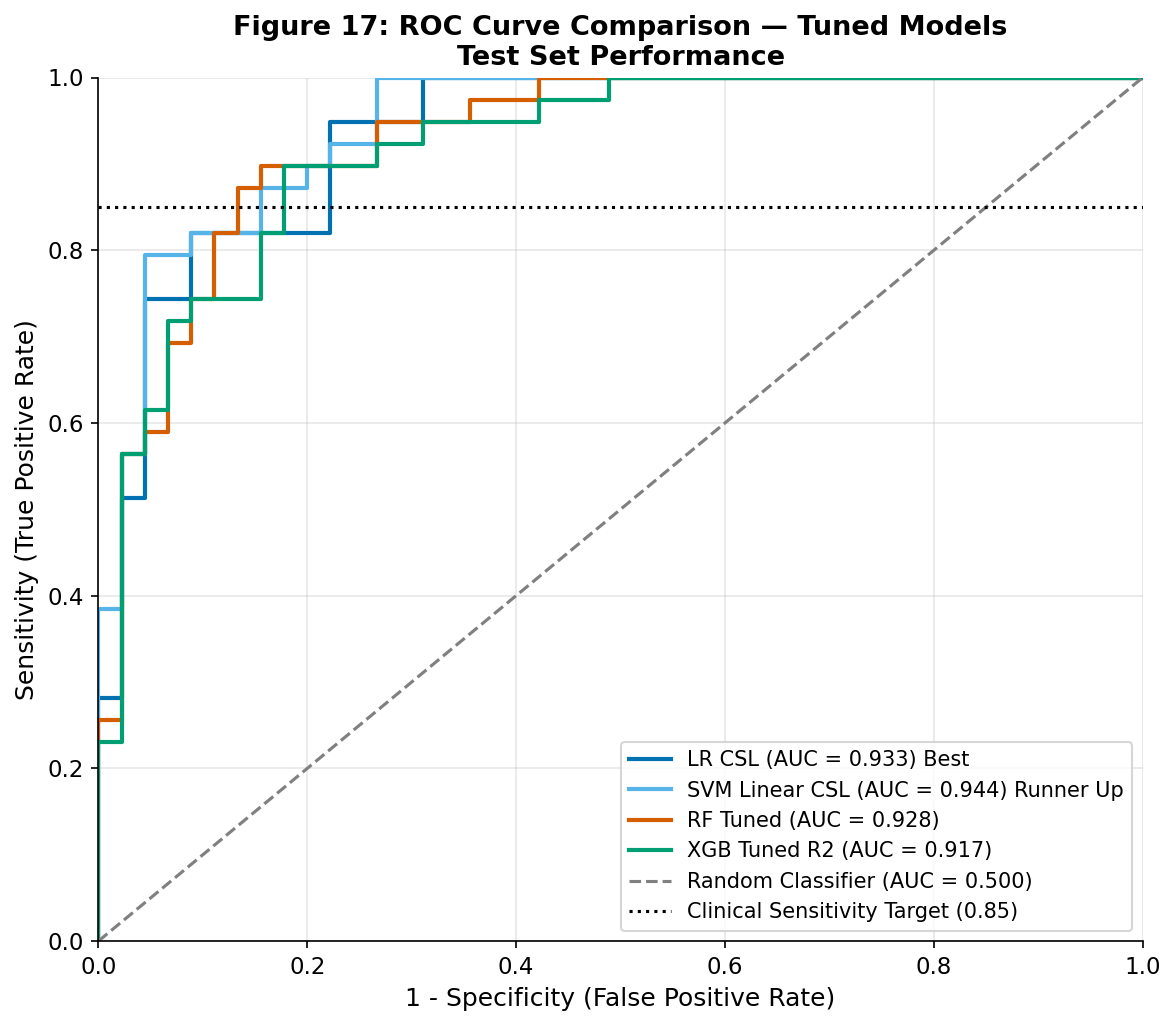

Figure 17 saved


In [47]:
# Plot ROC - AUC for tuned models

# Calculate ROC curves for each tuned model
fpr_lr_csl, tpr_lr_csl, _ = roc_curve(y_test, y_pred_proba_lr_csl)
fpr_rf_tuned, tpr_rf_tuned, _ = roc_curve(y_test, y_pred_proba_rf_tuned)
fpr_xgb_tuned_r2, tpr_xgb_tuned_r2, _ = roc_curve(y_test, y_pred_proba_xgb_tuned_r2)
fpr_svm_linear_csl, tpr_svm_linear_csl, _ = roc_curve(y_test, y_pred_proba_svm_linear_csl)

# Plot
fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(fpr_lr_csl, tpr_lr_csl,
        color='#0072B2', lw=2,
        label=f'LR CSL (AUC = {roc_auc_csl:.3f}) Best')

ax.plot(fpr_svm_linear_csl, tpr_svm_linear_csl,
        color='#56B4E9', lw=2,
        label=f'SVM Linear CSL (AUC = {roc_auc_svm_linear_csl:.3f}) Runner Up')

ax.plot(fpr_rf_tuned, tpr_rf_tuned,
        color='#D55E00', lw=2,
        label=f'RF Tuned (AUC = {roc_auc_rf_tuned:.3f})')

ax.plot(fpr_xgb_tuned_r2, tpr_xgb_tuned_r2,
        color='#009E73', lw=2,
        label=f'XGB Tuned R2 (AUC = {roc_auc_xgb_tuned_r2:.3f})')

# Reference line
ax.plot([0, 1], [0, 1],
        color='grey', lw=1.5, linestyle='--',
        label='Random Classifier (AUC = 0.500)')

# Clinical sensitivity target
ax.axhline(y=0.85, color='black', lw=1.5, linestyle=':',
           label='Clinical Sensitivity Target (0.85)')

ax.set_xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
ax.set_ylabel('Sensitivity (True Positive Rate)', fontsize=12)
ax.set_title('Figure 17: ROC Curve Comparison — Tuned Models\nTest Set Performance',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure17_roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 17 saved")

SHAP

In [51]:
shap.initjs()

print(f"SHAP version: {shap.__version__}")

SHAP version: 0.51.0


In [53]:
# SHAP LR CSL
# LinearExplainer appropriate for logistic regressin models
# Use training data distribution as reference

explainer_lr_csl = shap.LinearExplainer( #explainer for LR models
    lr_csl,
    X_train_encoded,
    feature_perturbation='interventional' #interventional treats features as independant, good for clinical data
)

# Calculate SHAP values on test set
shap_values_lr_csl = explainer_lr_csl.shap_values(X_test_encoded)

print(f"SHAP values shape: {shap_values_lr_csl.shape}")

SHAP values shape: (84, 16)


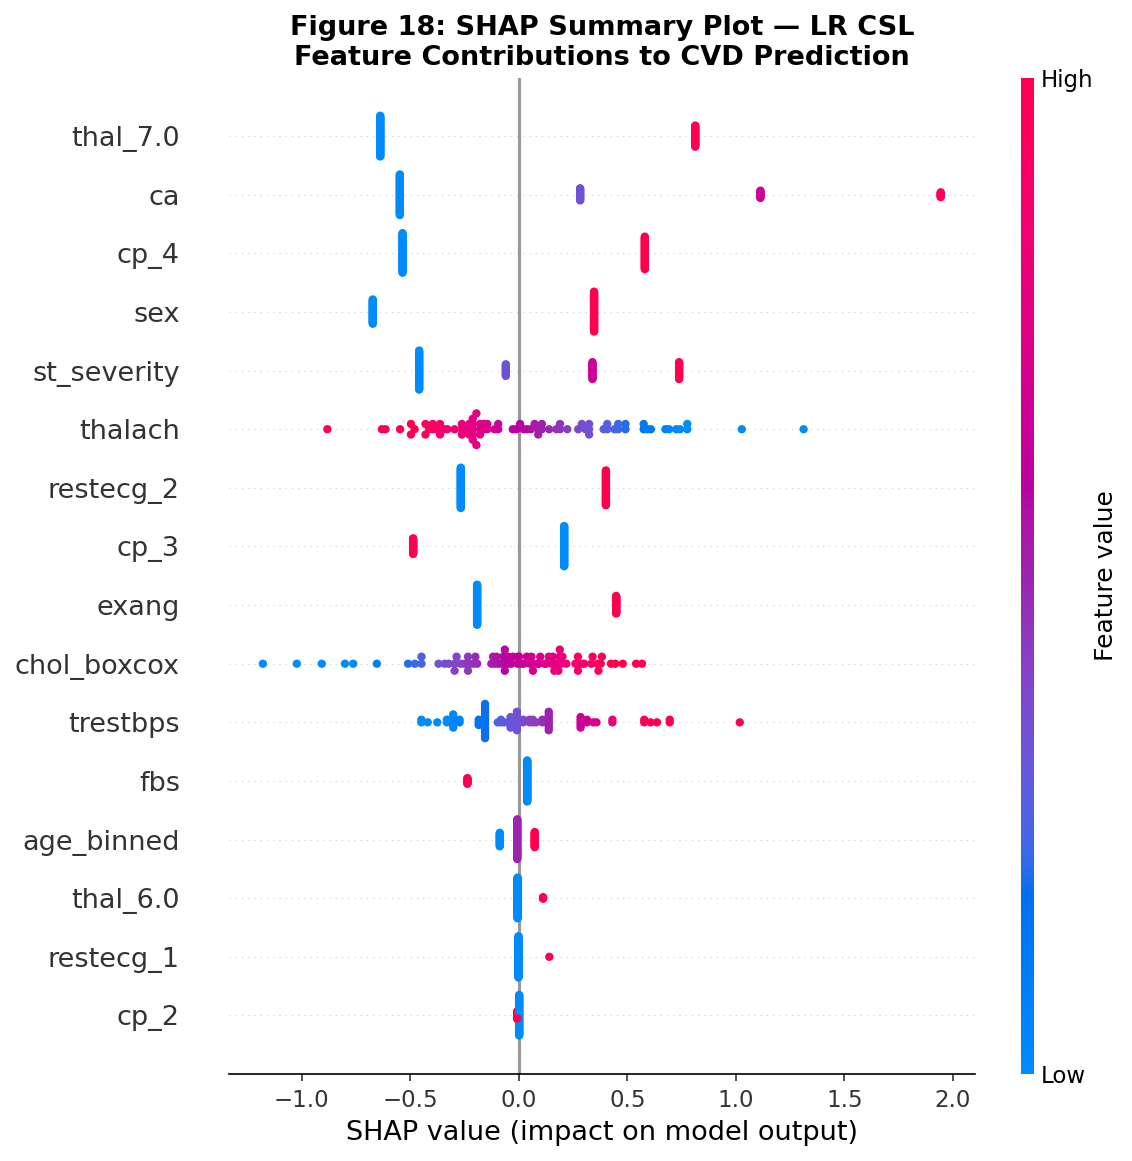

Figure 18 saved


In [55]:
# SHAP SUmmary Plot - LR CSL

plt.figure()
# Ensure shap_values_lr_csl is a standard numpy array of floats
shap_values_for_plot = np.asarray(shap_values_lr_csl, dtype=float)

shap.summary_plot(
    shap_values_for_plot, # Use the explicitly cast SHAP values
    X_test_encoded,
    feature_names=X_test_encoded.columns.tolist(),
    plot_type='dot',
    show=False
)

plt.title('Figure 18: SHAP Summary Plot — LR CSL\nFeature Contributions to CVD Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figure18_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 18 saved")

Threshold Analysis

In [56]:
# Threshold analysis
# Testing thresholds from 0.1 to 0.9 in 0.05 increments
# Clinincal targets: Sensitivity >= 0.85, Specificity >= 0.75

thresholds = np.arange(0.1, 0.95, 0.05) # array of thresholds

def threshold_analysis(y_test, y_pred_proba, model_name): # function to take any models probability and analyze
    results = []
    for threshold in thresholds:
        y_pred_t = (y_pred_proba >= threshold).astype(int) # at each threshold, coverts probablities to binary
        cm_t = confusion_matrix(y_test, y_pred_t)
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

        sensitivity = tp_t / (tp_t + fn_t)
        specificity = tn_t / (tn_t + fp_t)

        results.append({
            'Model': model_name,
            'Threshold': round(threshold, 2),
            'Sensitivity': round(sensitivity, 3),
            'Specificity': round(specificity, 3),
            'FN': fn_t,
            'FP': fp_t,
            'Meets_Target': sensitivity >= 0.85 and specificity >= 0.75
        })
    return pd.DataFrame(results)

print("Threshold analysis function defined")

Threshold analysis function defined


In [57]:
# Run threshold analysis for all tuned models

thresh_lr_csl = threshold_analysis(y_test, y_pred_proba_lr_csl, 'LR CSL')
thresh_rf_tuned = threshold_analysis(y_test, y_pred_proba_rf_tuned, 'RF Tuned')
thresh_xgb_tuned_r2 = threshold_analysis(y_test, y_pred_proba_xgb_tuned_r2, 'XGB Tuned R2')
thresh_svm_linear_csl = threshold_analysis(y_test, y_pred_proba_svm_linear_csl, 'SVM Linear CSL')

# Combine into one dataframe
thresh_all = pd.concat([thresh_lr_csl, thresh_rf_tuned, thresh_xgb_tuned_r2, thresh_svm_linear_csl],
                        ignore_index=True)

# Show only rows that meet clinical targets
meets_target = thresh_all[thresh_all['Meets_Target'] == True]

print("Thresholds meeting clinical targets (Sensitivity >= 0.85, Specificity >= 0.75):")
print("=" * 75)
print(meets_target.to_string(index=False))

Thresholds meeting clinical targets (Sensitivity >= 0.85, Specificity >= 0.75):
         Model  Threshold  Sensitivity  Specificity  FN  FP  Meets_Target
        LR CSL       0.25        0.949        0.778   2  10          True
        LR CSL       0.30        0.949        0.778   2  10          True
      RF Tuned       0.40        0.897        0.844   4   7          True
  XGB Tuned R2       0.25        0.897        0.778   4  10          True
SVM Linear CSL       0.30        0.923        0.778   3  10          True
SVM Linear CSL       0.35        0.897        0.778   4  10          True


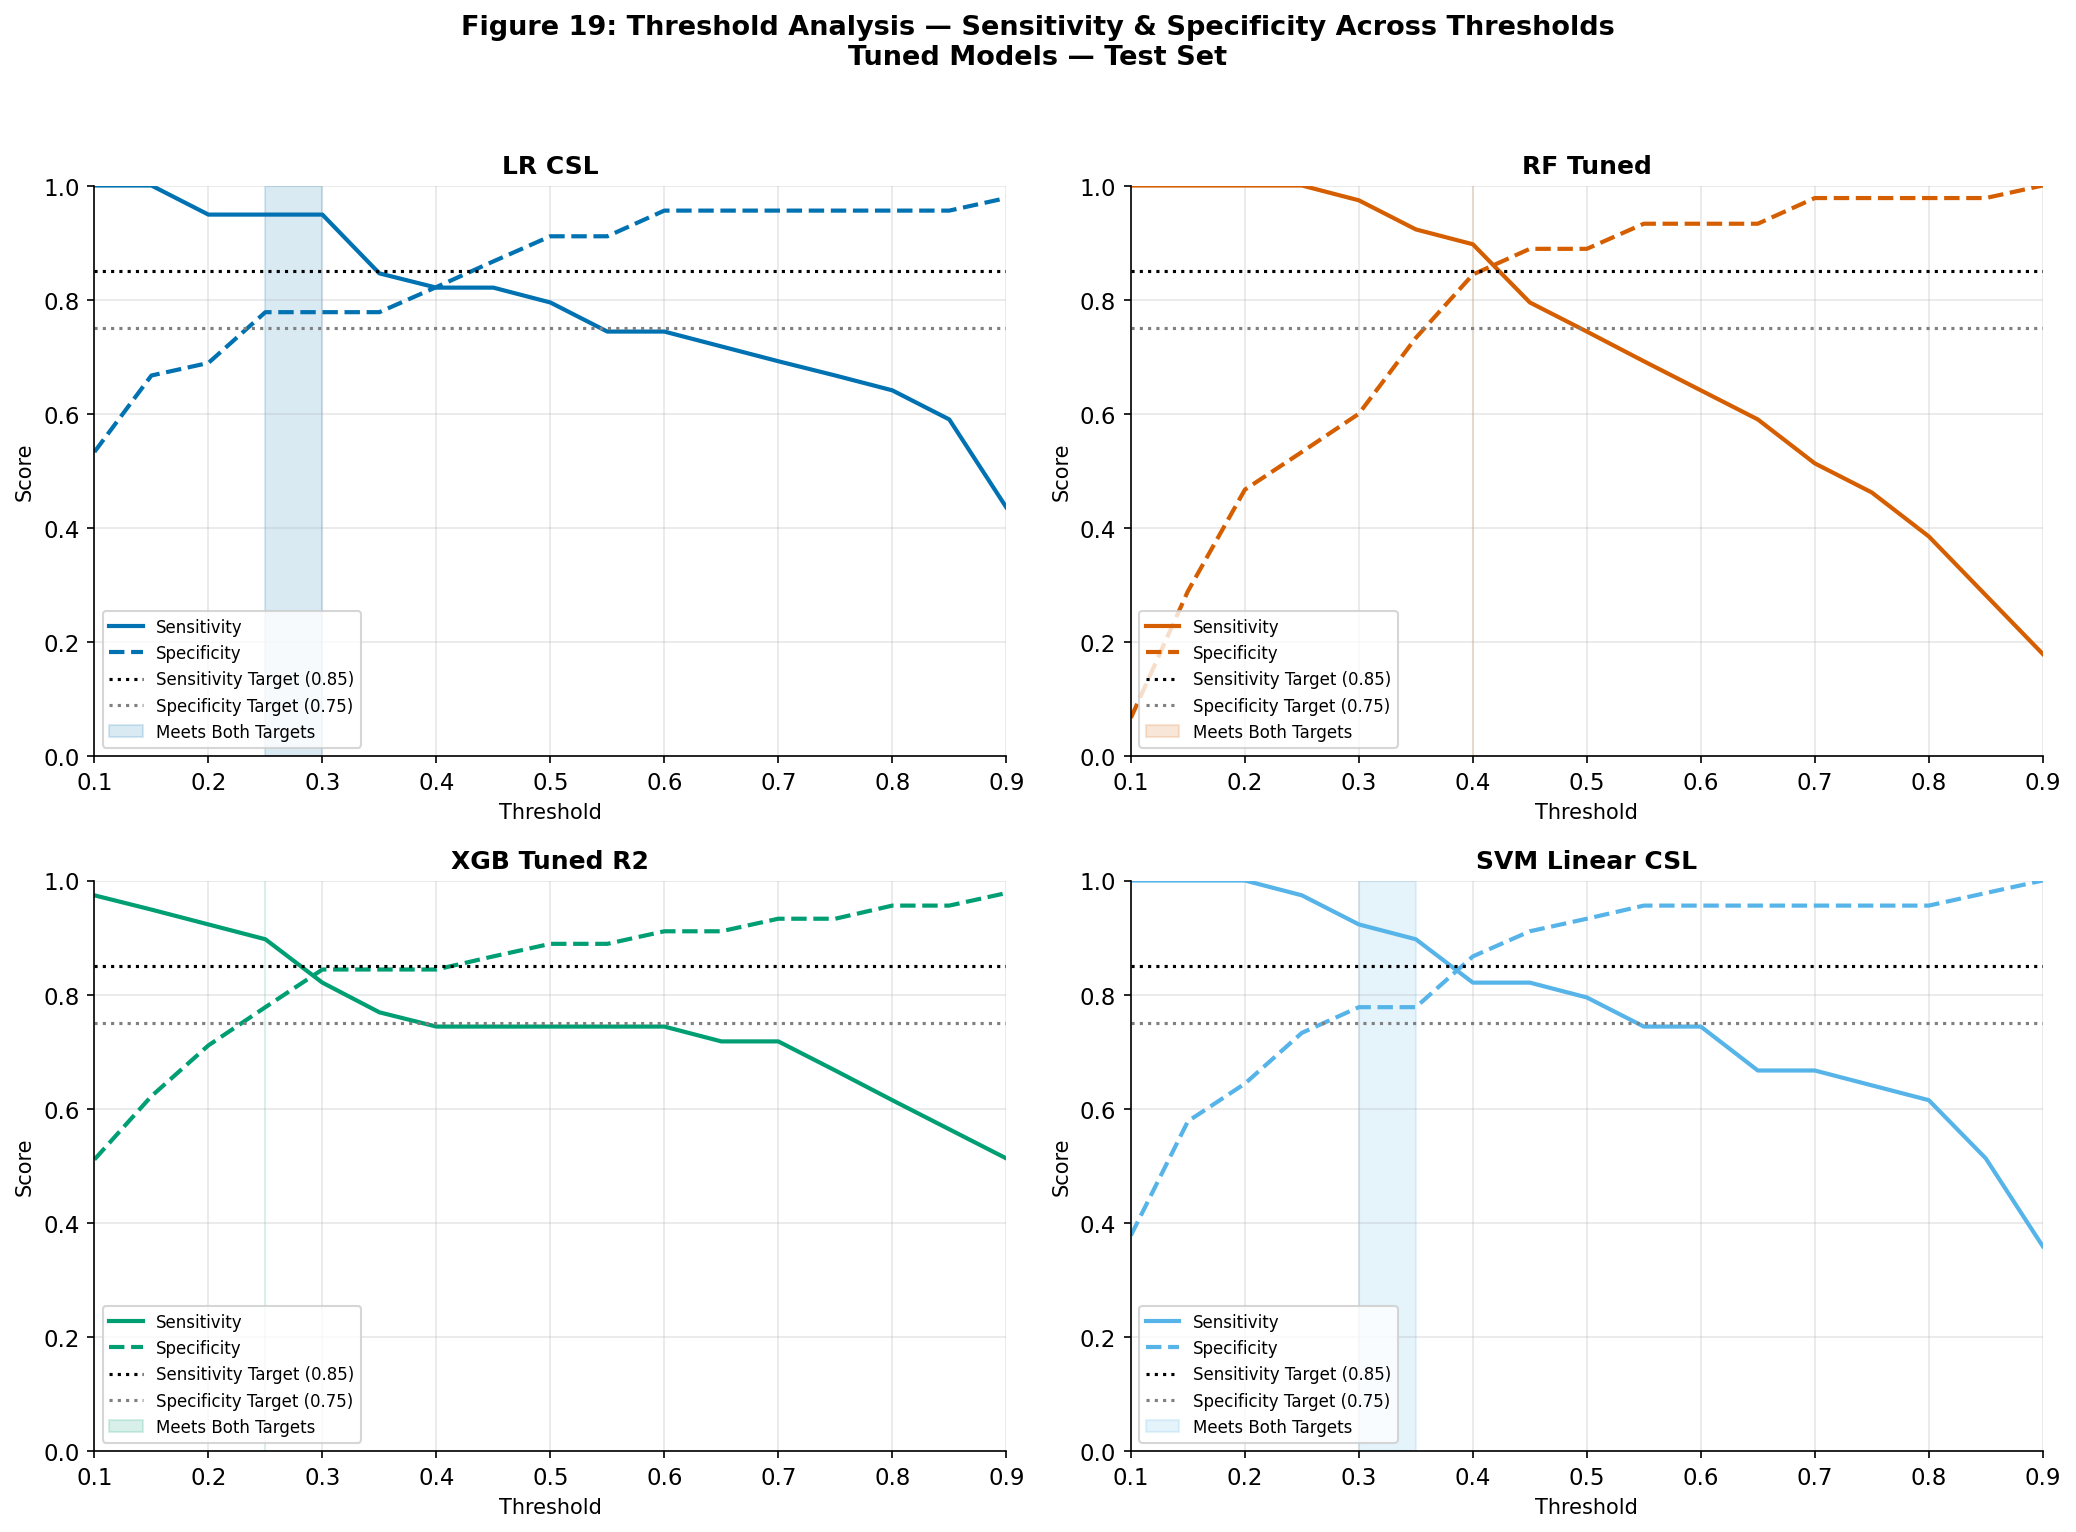

Figure 19 saved


In [65]:
# Threshold Analysis Plot

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models = [
    ('LR CSL', thresh_lr_csl, '#0072B2'),
    ('RF Tuned', thresh_rf_tuned, '#D55E00'),
    ('XGB Tuned R2', thresh_xgb_tuned_r2, '#009E73'),
    ('SVM Linear CSL', thresh_svm_linear_csl, '#56B4E9')
]

for idx, (name, df, color) in enumerate(models):
    ax = axes[idx]

    ax.plot(df['Threshold'], df['Sensitivity'],
            color=color, lw=2, label='Sensitivity')
    ax.plot(df['Threshold'], df['Specificity'],
            color=color, lw=2, linestyle='--', label='Specificity')

    # Clinical target lines
    ax.axhline(y=0.85, color='black', lw=1.5, linestyle=':',
               label='Sensitivity Target (0.85)')
    ax.axhline(y=0.75, color='grey', lw=1.5, linestyle=':',
               label='Specificity Target (0.75)')

    # Shade the meeting target region
    meets = df[df['Meets_Target'] == True]
    if len(meets) > 0:
        ax.axvspan(meets['Threshold'].min(),
                   meets['Threshold'].max(),
                   alpha=0.15, color=color,
                   label='Meets Both Targets')

    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Threshold', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_xlim([0.1, 0.9])
    ax.set_ylim([0, 1])
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.3)

plt.suptitle('Figure 19: Threshold Analysis — Sensitivity & Specificity Across Thresholds\nTuned Models — Test Set',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('figure19_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 19 saved")

##Decision Curve Analysis

In [68]:
print(f"dcurves version: {dcurves.__version__}")
print("dcurves imported")

dcurves version: 1.1.7
dcurves imported


In [69]:
# DCA requires a single dataframe with outcome and predicted probabilities
# dcurves expects: outcome column + one column per model probability

dca_df = pd.DataFrame({
    'cvd': y_test.values,
    'LR_CSL': y_pred_proba_lr_csl,
    'RF_Tuned': y_pred_proba_rf_tuned,
    'XGB_Tuned_R2': y_pred_proba_xgb_tuned_r2,
    'SVM_Linear_CSL': y_pred_proba_svm_linear_csl
})

print(f"DCA dataframe shape: {dca_df.shape}")
print(f"\nFirst 5 rows:")
print(dca_df.head())
print(f"\nCVD prevalence: {dca_df['cvd'].mean():.3f}")

DCA dataframe shape: (84, 5)

First 5 rows:
   cvd    LR_CSL  RF_Tuned  XGB_Tuned_R2  SVM_Linear_CSL
0    1  0.862644  0.633722      0.728320        0.901268
1    0  0.239973  0.436605      0.148076        0.232941
2    0  0.009243  0.079578      0.009939        0.020793
3    1  0.191189  0.273799      0.095975        0.277087
4    0  0.024727  0.148128      0.035522        0.044054

CVD prevalence: 0.464


In [70]:
# Run Decision Curve Analysis
dca_results = dca(
    data=dca_df,
    outcome='cvd',
    modelnames=['LR_CSL', 'RF_Tuned', 'XGB_Tuned_R2', 'SVM_Linear_CSL'],
    thresholds=np.arange(0.01, 0.50, 0.01)
)

print("DCA complete")
print(dca_results.head(10))

DCA complete
    model  threshold   n  prevalence  harm  test_pos_rate   tp_rate   fp_rate  \
0  LR_CSL       0.01  84    0.464286   0.0       0.964286  0.464286  0.500000   
1  LR_CSL       0.02  84    0.464286   0.0       0.940476  0.464286  0.476190   
2  LR_CSL       0.03  84    0.464286   0.0       0.892857  0.464286  0.428571   
3  LR_CSL       0.04  84    0.464286   0.0       0.869048  0.464286  0.404762   
4  LR_CSL       0.05  84    0.464286   0.0       0.845238  0.464286  0.380952   
5  LR_CSL       0.06  84    0.464286   0.0       0.797619  0.464286  0.333333   
6  LR_CSL       0.07  84    0.464286   0.0       0.773810  0.464286  0.309524   
7  LR_CSL       0.08  84    0.464286   0.0       0.750000  0.464286  0.285714   
8  LR_CSL       0.09  84    0.464286   0.0       0.726190  0.464286  0.261905   
9  LR_CSL       0.10  84    0.464286   0.0       0.714286  0.464286  0.250000   

   net_benefit  net_intervention_avoided  
0     0.459235                  0.035714  
1     0.4

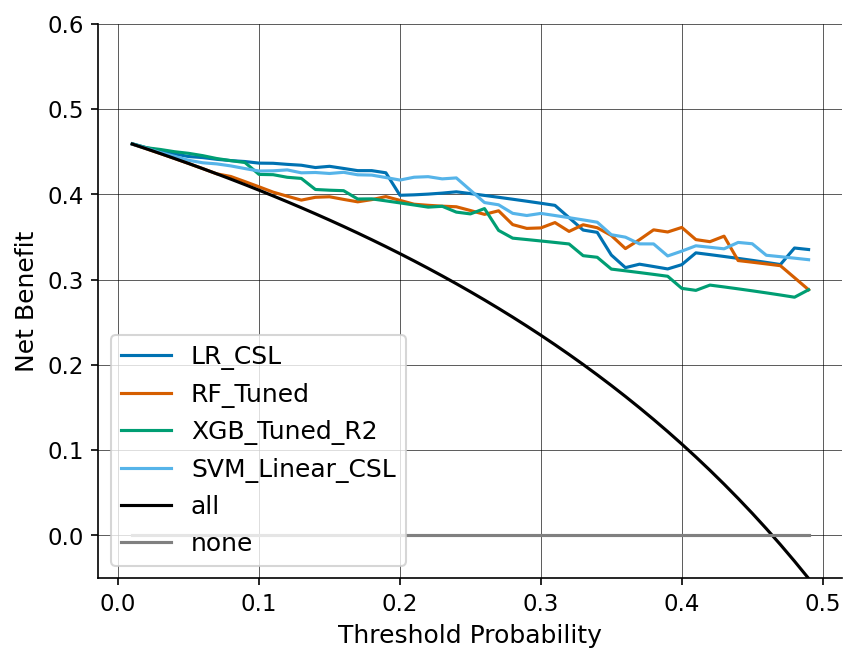

<Figure size 960x720 with 0 Axes>

Figure 20 saved


In [80]:
# Figure 20 - Decision Curve Analysis

plot_graphs(
    plot_df=dca_results,
    graph_type='net_benefit',
    y_limits=[-0.05, 0.6],
    color_names=['#0072B2', '#D55E00', '#009E73', '#56B4E9', 'black', 'grey']
)

plt.savefig('figure20_dca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 20 saved")

## Export Final Model

In [81]:
# LR CSL - Final Validated Model
# Threshold: 0.25

from datetime import date

joblib.dump(lr_csl, '/content/drive/MyDrive/lr_csl_final.pkl')

print("=" * 50)
print("FINAL MODEL EXPORT")
print("=" * 50)
print(f"Model: Logistic Regression with CSL")
print(f"Export date: {date.today()}")
print(f"Threshold: 0.25")
print(f"File exported: lr_csl_final.pkl")
print(f"\nModel parameters:")
print(lr_csl.get_params())

FINAL MODEL EXPORT
Model: Logistic Regression with CSL
Export date: 2026-04-27
Threshold: 0.25
File exported: lr_csl_final.pkl

Model parameters:
{'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
